In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split,KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import f_regression
from sklearn.metrics import f1_score, precision_score, confusion_matrix, recall_score, accuracy_score
from sklearn.model_selection import train_test_split


In [5]:
df = pd.read_csv("expenses.csv")

df.head()
df.tail()
df.describe()
# df.info()
# df.isnull().sum()
# df.nunique()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

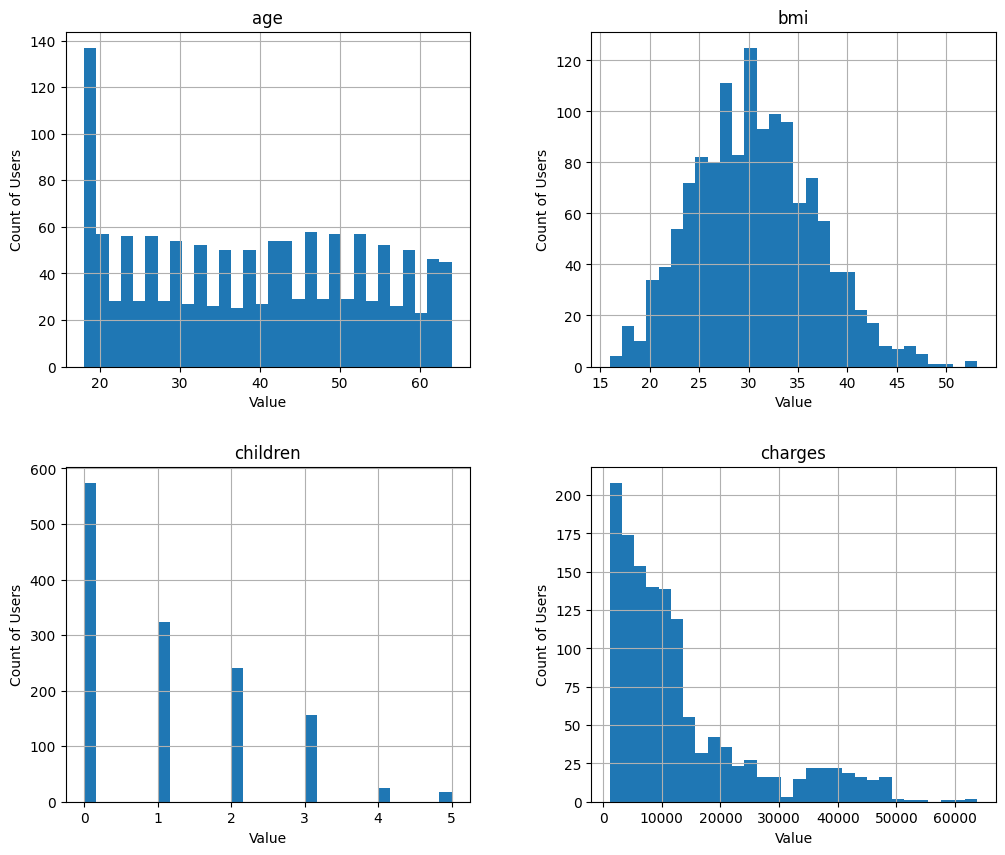

In [27]:
axes = df.hist(bins=30, figsize=(12,10))
for ax in axes.flatten():
    ax.set_xlabel("Value")
    ax.set_ylabel("Count of Users")
plt.show()



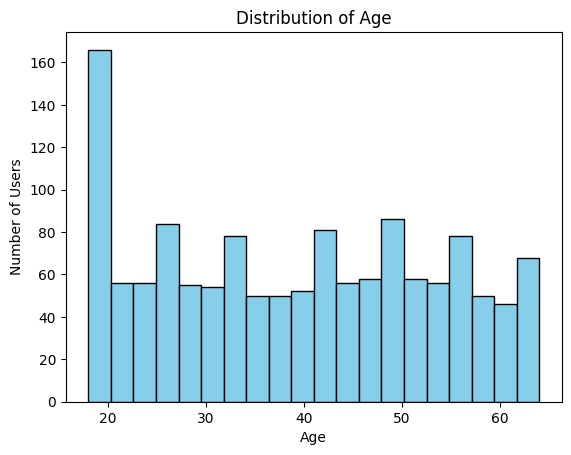

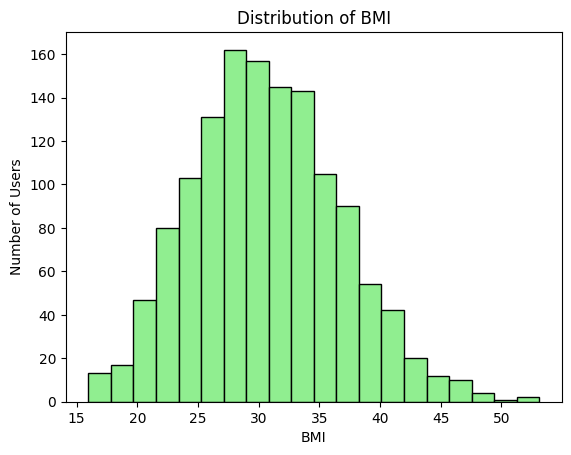

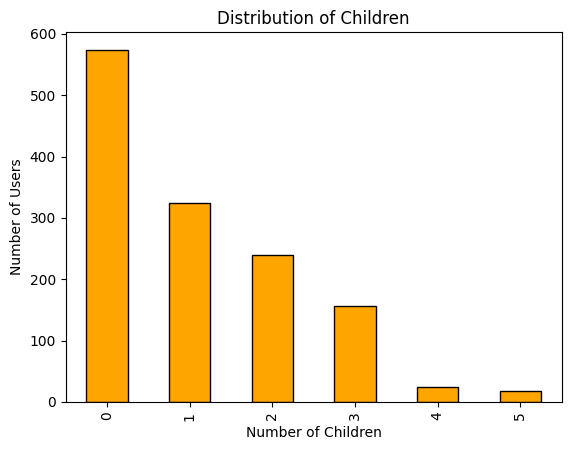

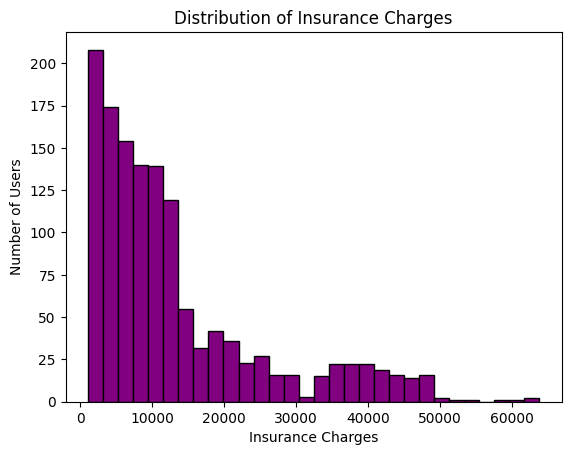

In [26]:
plt.hist(df['age'], bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.title("Distribution of Age")
plt.show()

# BMI histogram
plt.hist(df['bmi'], bins=20, color="lightgreen", edgecolor="black")
plt.xlabel("BMI")
plt.ylabel("Number of Users")
plt.title("Distribution of BMI")
plt.show()

# Children bar plot (better for discrete values)
df['children'].value_counts().sort_index().plot(kind='bar', color="orange", edgecolor="black")
plt.xlabel("Number of Children")
plt.ylabel("Number of Users")
plt.title("Distribution of Children")
plt.show()

# Charges histogram
plt.hist(df['charges'], bins=30, color="purple", edgecolor="black")
plt.xlabel("Insurance Charges")
plt.ylabel("Number of Users")
plt.title("Distribution of Insurance Charges")
plt.show()

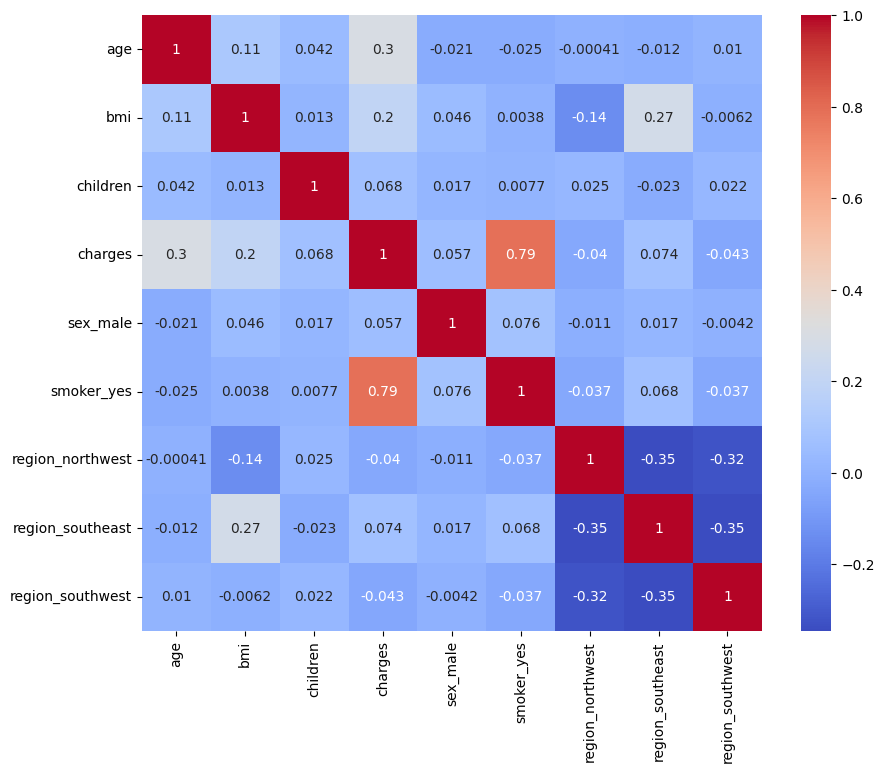

In [7]:
df_encoded = pd.get_dummies(df,drop_first=True)
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(),annot=True , cmap="coolwarm")
plt.show()

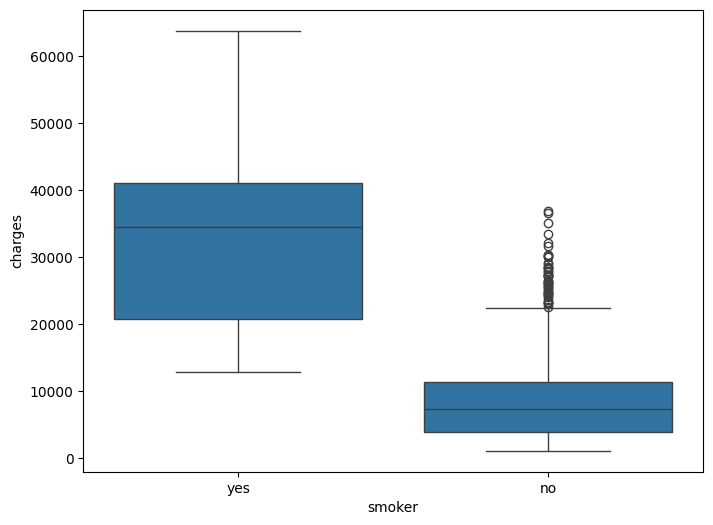

In [7]:
plt.figure(figsize=(8,6))
sns.boxplot(x="smoker",y="charges",data=df)
plt.show()

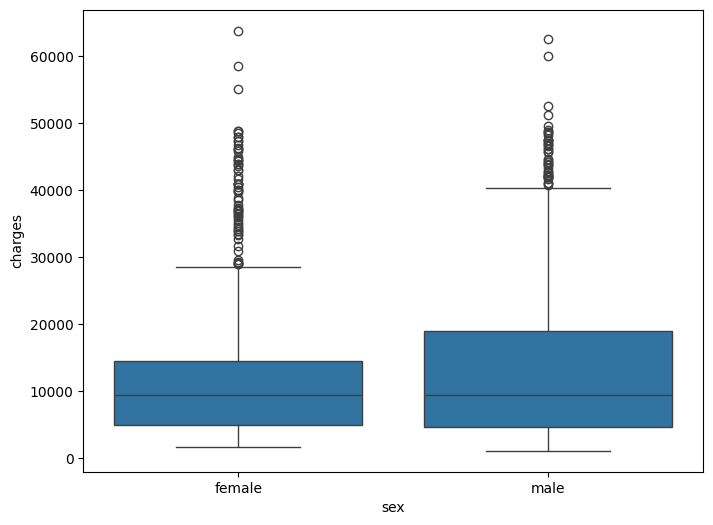

In [9]:
plt.figure(figsize=(8,6))
sns.boxplot(x="sex",y="charges",data=df)
plt.show()

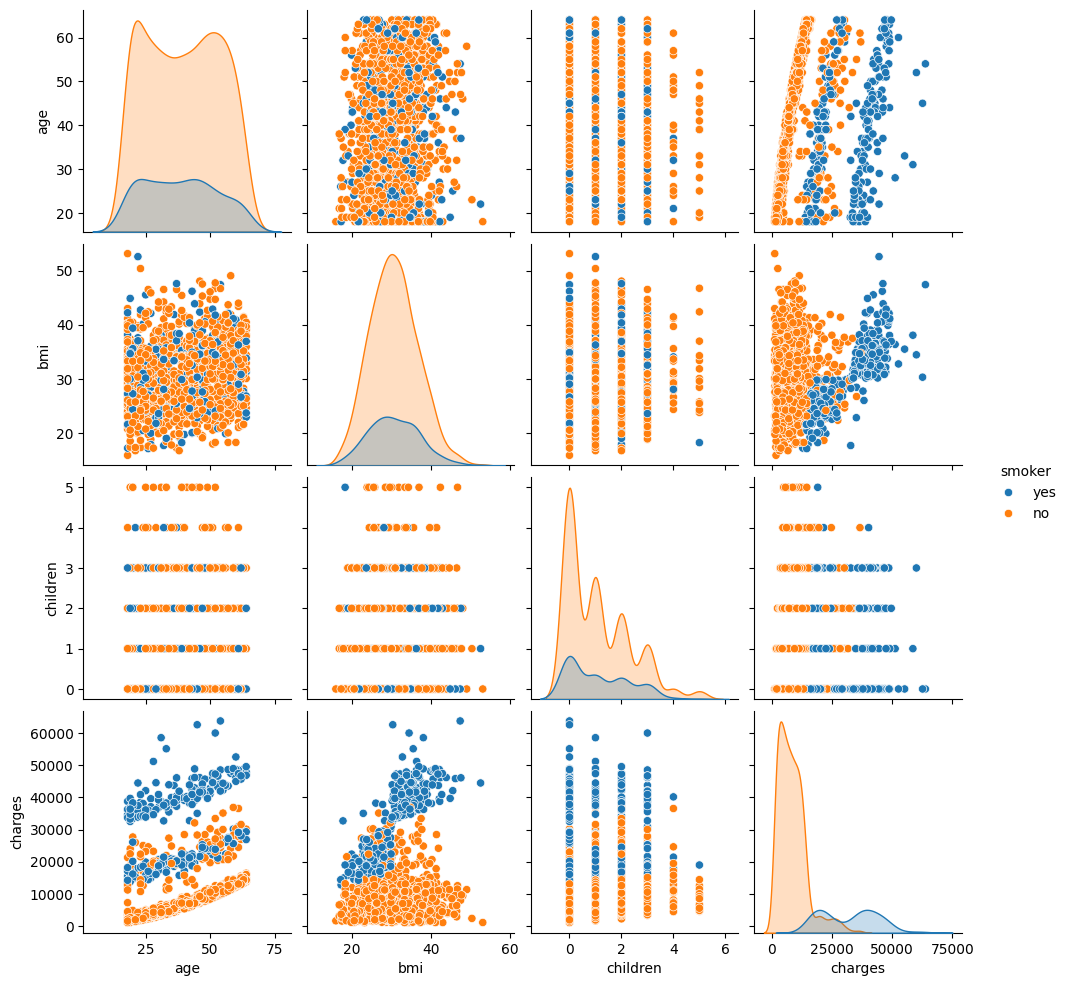

In [10]:
sns.pairplot(df,hue="smoker")
plt.show()

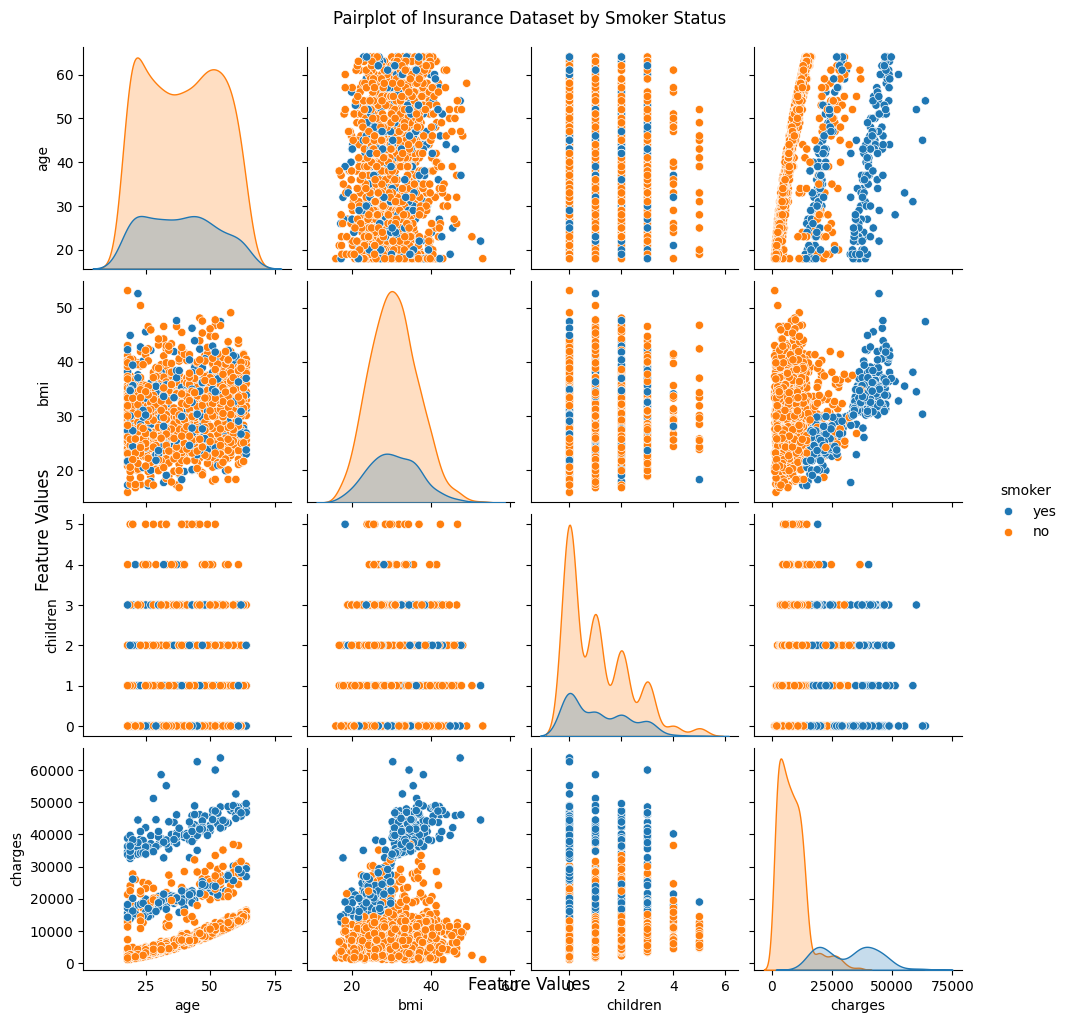

In [8]:
g = sns.pairplot(df, hue="smoker")

g.fig.suptitle("Pairplot of Insurance Dataset by Smoker Status", y=1.02)
g.fig.text(0.5, 0.04, "Feature Values", ha="center", fontsize=12)   # X-axis label
g.fig.text(0.04, 0.5, "Feature Values", va="center", rotation="vertical", fontsize=12)  # Y-axis label

plt.show()

In [11]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['charges'] < lower) | (df['charges'] > upper)]
print("Outliers in charges:", len(outliers))

Outliers in charges: 139


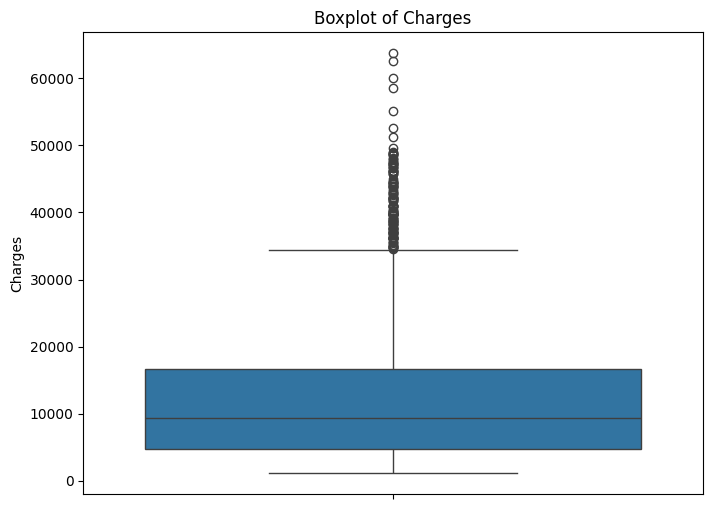

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(y=df["charges"])
plt.title("Boxplot of Charges")
plt.ylabel("Charges")
plt.show()

In [ ]:
print("Unique values in 'sex':", df['sex'].unique())
print("Unique values in 'smoker':", df['smoker'].unique())
print("Unique values in 'region':", df['region'].unique())

df['sex'] = df['sex'].str.lower().str.strip()
df['smoker'] = df['smoker'].str.lower().str.strip()
df['region'] = df['region'].str.lower().str.strip()

print("\nAny negative ages?", (df['age'] < 0).any())
print("Any unrealistic ages (>100)?", (df['age'] > 100).any())

print("\nAny BMI <= 0?", (df['bmi'] <= 0).any())
print("Any Children < 0?", (df['children'] < 0).any())
print("Any Charges < 0?", (df['charges'] < 0).any())

Unique values in 'sex': ['female' 'male']
Unique values in 'smoker': ['yes' 'no']
Unique values in 'region': ['southwest' 'southeast' 'northwest' 'northeast']

Any negative ages? False
Any unrealistic ages (>100)? False

Any BMI <= 0? False
Any Children < 0? False
Any Charges < 0? False


In [12]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())



   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:
# Scale numeric columns
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Convert boolean columns to int (0/1)
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes('bool').columns})

# Log-transform target
df_encoded["charges_log"] = np.log1p(df_encoded["charges"])


Correlation with log(charges):
 charges_log         1.000000
charges             0.892996
smoker_yes          0.665539
age                 0.527807
children            0.161317
bmi                 0.132678
region_southeast    0.015803
sex_male            0.005644
region_northwest   -0.017830
region_southwest   -0.041633
Name: charges_log, dtype: float64


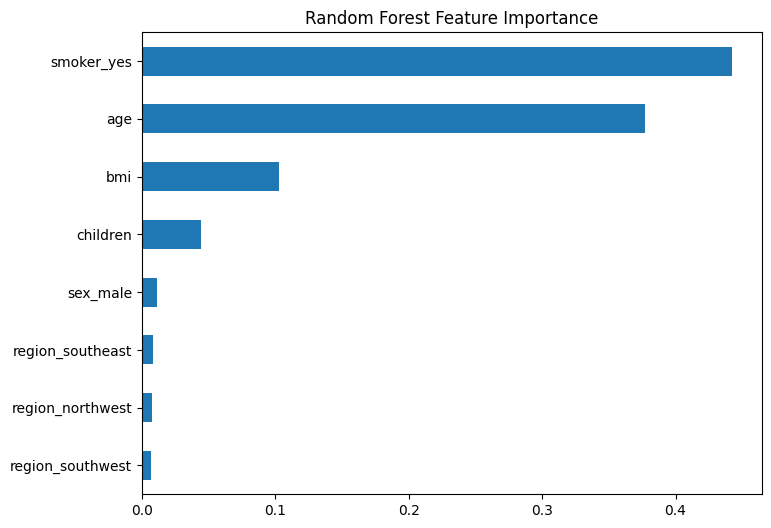


ANOVA F-test Results:
             Feature      F_Score        p_value
4        smoker_yes  1062.316552  5.977829e-172
0               age   515.904764   7.675384e-97
2          children    35.695701   2.953906e-09
1               bmi    23.939625   1.114880e-06
7  region_southwest     2.319676   1.279833e-01
5  region_northwest     0.424873   5.146277e-01
6  region_southeast     0.333709   5.635806e-01
3          sex_male     0.042564   8.365806e-01


In [13]:
# Correlation with target
corr = df_encoded.corr()['charges_log'].sort_values(ascending=False)
print("\nCorrelation with log(charges):\n", corr)

# Random Forest feature importance
X = df_encoded.drop(["charges", "charges_log"], axis=1)
y = df_encoded["charges_log"]

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Random Forest Feature Importance")
plt.show()

# ANOVA F-test
f_scores, p_values = f_regression(X, y)
anova = pd.DataFrame({"Feature": X.columns, "F_Score": f_scores, "p_value": p_values})
print("\nANOVA F-test Results:\n", anova.sort_values(by="F_Score", ascending=False))


In [14]:
# Final dataset checks
# print("\nHead of dataset:\n", df_encoded.head())
# print("\nTail of dataset:\n", df_encoded.tail())
# print("\nShape:", df_encoded.shape)
# print("\nInfo:\n")
# print(df_encoded.info())
# print("\nDescribe:\n", df_encoded.describe())
print("\nHead of dataset:\n")
print(df_encoded.head())

print("\nTail of dataset:\n")
print(df_encoded.tail())

print("\nShape of dataset:\n")
print(df_encoded.shape)

print("\nColumns in dataset:\n")
print(df_encoded.columns)

print("\nData types of each column:\n")
print(df_encoded.dtypes)

print("\nInfo:\n")
print(df_encoded.info())

print("\nStatistical Summary (Describe):\n")
print(df_encoded.describe())

print("\nMissing Values in each column:\n")
print(df_encoded.isnull().sum())

print("\nUnique values in each column:\n")
print(df_encoded.nunique())

print("\nMemory usage of dataset:\n")
print(df_encoded.memory_usage(deep=True))




Head of dataset:

        age       bmi  children      charges  sex_male  smoker_yes  \
0 -1.438764 -0.453320 -0.908614  16884.92400         0           1   
1 -1.509965  0.509621 -0.078767   1725.55230         1           0   
2 -0.797954  0.383307  1.580926   4449.46200         1           0   
3 -0.441948 -1.305531 -0.908614  21984.47061         1           0   
4 -0.513149 -0.292556 -0.908614   3866.85520         1           0   

   region_northwest  region_southeast  region_southwest  charges_log  
0                 0                 0                 1     9.734236  
1                 0                 1                 0     7.453882  
2                 0                 1                 0     8.400763  
3                 1                 0                 0     9.998137  
4                 1                 0                 0     8.260455  

Tail of dataset:

           age       bmi  children     charges  sex_male  smoker_yes  \
1333  0.768473  0.050297  1.580926  10600.5

In [15]:
X = df_encoded.drop(["charges", "charges_log"], axis=1)
y = df_encoded["charges"]

# 80/20 split (same as IJERPH 2022 & Math 2023 papers)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1070, 8)
Test shape: (268, 8)


In [21]:
# from sklearn.metrics import classification_report, mean_absolute_error

# rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_regressor.fit(X_train, y_train)

# # 4. Make predictions on the test set
# y_pred = rf_regressor.predict(X_test)

# # 5. Evaluate the model
# mae = mean_absolute_error(y_test, y_pred)
# print(f"Mean Absolute Error (MAE): {mae}")

# # You can also access feature importances
# feature_importances = pd.Series(rf_regressor.feature_importances_, index=X.columns).sort_values(ascending=False)
# print("\nFeature Importances:")
# print(feature_importances)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train on raw charges
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predictions
y_pred = rf_regressor.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Feature importance
feature_importances = pd.Series(rf_regressor.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:\n", feature_importances)


Mean Absolute Error (MAE): 2545.21
Root Mean Squared Error (RMSE): 4567.96
R² Score: 0.8656

Feature Importances:
 smoker_yes          0.608618
bmi                 0.216506
age                 0.134232
children            0.019413
sex_male            0.006379
region_northwest    0.005587
region_southeast    0.005314
region_southwest    0.003950
dtype: float64


In [22]:
# Train with log target
X = df_encoded.drop(["charges", "charges_log"], axis=1)
y = df_encoded["charges_log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

y_pred_log = rf_regressor.predict(X_test)

# Convert predictions back to original scale
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"[Log-Transformed Target] MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")


[Log-Transformed Target] MAE: 2085.24, RMSE: 4359.13, R²: 0.8776


In [20]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

R² Score: 0.8655948876523016
Root Mean Squared Error (RMSE): 4567.956129166466


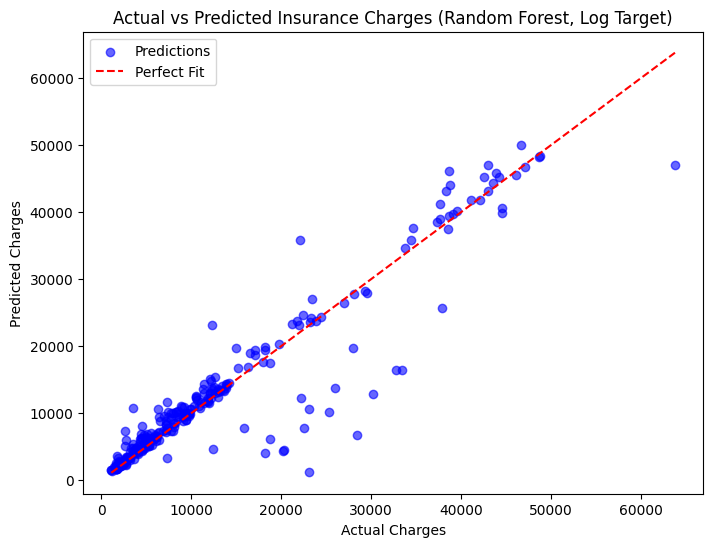

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.6, color="blue", label="Predictions")
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label="Perfect Fit")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges (Random Forest, Log Target)")
plt.legend()
plt.show()


In [ ]:
# Example: simulate new test cases (not in dataset)
new_data = pd.DataFrame({
    "age": [25, 60],
    "bmi": [22.5, 35.0],
    "children": [0, 2],
    "sex_male": [1, 0],
    "smoker_yes": [0, 1],
    "region_northwest": [0, 0],
    "region_southeast": [1, 0],
    "region_southwest": [0, 1]
})

# Apply scaling to new_data numeric cols
new_data[num_cols] = scaler.transform(new_data[num_cols])
print(new_data)


        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.011557 -1.339160 -0.908614         1           0                 0   
1  1.480485  0.711396  0.751079         0           1                 0   

   region_southeast  region_southwest  
0                 1                 0  
1                 0                 1  
